In [182]:
import onep
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import scipy
from scipy import stats
import scipy.stats
%matplotlib inline

In [ ]:
astro_3 = onep.InscopixProcessing(session='recall', animal='astro3', data_directory='/Users/suthardr/Desktop/')
astro_3.read_inscopix()

astro_4 = onep.InscopixProcessing(session='recall', animal='astro4', data_directory='/Users/suthardr/Desktop/')
astro_4.read_inscopix()

astro_5 = onep.InscopixProcessing(session='recall', animal='astro5', data_directory='/Users/suthardr/Desktop/')
astro_5.read_inscopix()

astro_6 = onep.InscopixProcessing(session='recall', animal='astro6', data_directory='/Users/suthardr/Desktop/')
astro_6.read_inscopix()

collection = onep.dCA1Group(astro_3, astro_4, astro_5, astro_6)
collection.preprocess()
recall_cxta_traces = collection.grab_all_traces()

In [ ]:
astro_7 = onep.InscopixProcessing(session='gen1', animal='astro7', data_directory='/Users/suthardr/Desktop/')
astro_7.read_inscopix()

astro_8 = onep.InscopixProcessing(session='gen1', animal='astro8', data_directory='/Users/suthardr/Desktop/')
astro_8.read_inscopix()

astro_9 = onep.InscopixProcessing(session='gen1', animal='astro9', data_directory='/Users/suthardr/Desktop/')
astro_9.read_inscopix()

astro_10 = onep.InscopixProcessing(session='gen1', animal='astro10', data_directory='/Users/suthardr/Desktop/')
astro_10.read_inscopix()

collection2 = onep.dCA1Group(astro_7, astro_8, astro_9, astro_10)
collection2.preprocess()
recall_cxtb_traces = collection2.grab_all_traces()

In [ ]:
#Make the dataframe look the way we need
#Transpose
recall_cxtb_traces_transpose = recall_cxtb_traces.T
recall_cxtb_traces

In [418]:
#Grab timestamps from the first row
timestamps = recall_cxtb_traces.iloc[:1,0:3303]
timestamps

,index,C00,C01,C02,C03,C04,C05,C06,C07,C08,...,C82,C83,C85,C86,C91,C92,C93,C97,C98,C99
0,0.0,0.122533,0.070008,0.090351,0.013764,0.095051,0.031643,0.0441,-0.004427,0.008564,...,0.00775,0.000469,0.005205,0.000566,0.008262,-0.001284,0.000899,0.018365,-0.001559,0.002069


In [ ]:
#Delete the timestamps row
numpy = np.delete(recall_cxtb_traces, 0, 0)
numpy

In [420]:
#Cut off at 3303 indices
numpy = numpy[:,:3303]

In [ ]:
#Z-score your numpy array
numpy_z = stats.zscore(numpy, axis=1)
numpy_z

In [180]:
np.save('/Users/suthardr/Desktop/recall_cxtb_preprocessed_z.npy', numpy_z)
#Save all accepted_traces for all animals in one group as numpy array

In [228]:
#Messing around with timestamps format until it works RIP
timestamps=timestamps.T
timestamps

,0,1,2,3,4,5,6,7,8,9,...,3293,3294,3295,3296,3297,3298,3299,3300,3301,3302
,,,,,,,,,,,,,,,,,,,,,
index,0.0,0.099923,0.199847,0.29977,0.399694,0.499617,0.599541,0.699464,0.799388,0.899311,...,329.047964,329.147888,329.247811,329.347735,329.447658,329.547582,329.647505,329.747429,329.847352,329.947276


In [232]:
timestamps = timestamps.to_numpy().T
timestamps

AttributeError: 'numpy.ndarray' object has no attribute 'to_numpy'

In [521]:
#Grab all accepted_traces from a single mouse for plotting
sliced_df = astro_3.accepted_traces.to_numpy()[:3303]

In [ ]:
#Plot ETA for foot shock timing for all individual cells
ax, across_eta_ = onep.eta_individual_cells(data=sliced_df.T, timestamps=t[:3303], events=[[120,180,240,300], ], window=15)

<Axes: >

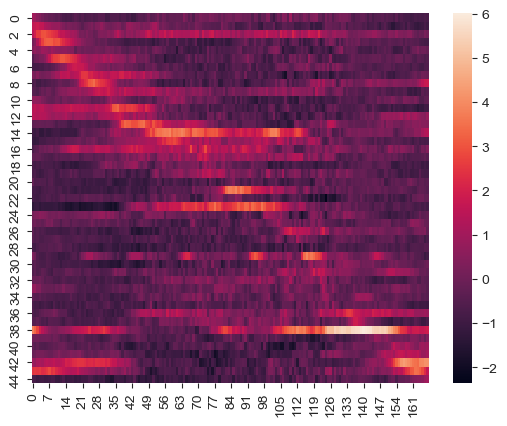

In [526]:
#Plot sorted heatmap for that shock ETA
across_eta_ = stats.zscore(across_eta_)
max_indices = np.argmax(across_eta_, axis=1)
sorted_ind = np.argsort(max_indices)
sorted_arr = across_eta_[sorted_ind]
sns.heatmap(sorted_arr)

In [498]:
#Import cluster-specific numpy arrays from WaveMAP
cluster1 = np.load("/Users/suthardr/Desktop/cluster1_cxta_recall.npy")
cluster0 = np.load("/Users/suthardr/Desktop/cluster0_cxta_recall.npy")
cluster2 = np.load("/Users/suthardr/Desktop/cluster2_cxta_recall.npy")
cluster3 = np.load("/Users/suthardr/Desktop/cluster3_cxta_recall.npy")

In [499]:
#Cut off at 3303 indices (~330 seconds)
cluster1 = cluster1[:,:3303]

cluster0 = cluster0[:,:3303]

cluster2 = cluster2[:,:3303]

cluster3 = cluster3[:,:3303]

In [ ]:
#Plot each cluster from WaveMAP for shock-timing
fig, ax = plt.subplots()
sns.set_style("ticks")
#Shock timing
onep.eta_averaged(data=cluster0, timestamps=t, events=[[120,180,240,300], ], window=15, ci='tci', sig_duration=8, ax=ax, color='red')
onep.eta_averaged(data=cluster1, timestamps=t, events=[[120,180,240,300], ], window=15, ci='tci', sig_duration=8, ax=ax, color='green')
onep.eta_averaged(data=cluster2, timestamps=t, events=[[120,180,240,300], ], window=15, ci='tci', sig_duration=8, ax=ax, color='blue')
onep.eta_averaged(data=cluster3, timestamps=t, events=[[120,180,240,300], ], window=15, ci='tci', sig_duration=8, ax=ax, color='purple')

#30 Seconds
onep.eta_averaged(data=cluster0, timestamps=t, events=[[30,60,90,120,150,180,210,240,270,300], ], window=15, ci='tci', sig_duration=8, ax=ax, color='red')
onep.eta_averaged(data=cluster1, timestamps=t, events=[[30,60,90,120,150,180,210,240,270,300], ], window=15, ci='tci', sig_duration=8, ax=ax, color='green')
onep.eta_averaged(data=cluster2, timestamps=t, events=[[30,60,90,120,150,180,210,240,270,300], ], window=15, ci='tci', sig_duration=8, ax=ax, color='blue')
onep.eta_averaged(data=cluster3, timestamps=t, events=[[30,60,90,120,150,180,210,240,270,300], ], window=15, ci='tci', sig_duration=8, ax=ax, color='purple')


#30 Seconds without Shock Times
onep.eta_averaged(data=cluster0, timestamps=t, events=[[30,90,150,210,270], ], window=15, ci='tci', sig_duration=8, ax=ax, color='red')
onep.eta_averaged(data=cluster1, timestamps=t, events=[[30,90,150,210,270], ], window=15, ci='tci', sig_duration=8, ax=ax, color='green')
onep.eta_averaged(data=cluster2, timestamps=t, events=[[30,90,150,210,270], ], window=15, ci='tci', sig_duration=8, ax=ax, color='blue')
onep.eta_averaged(data=cluster3, timestamps=t, events=[[30,90,150,210,270], ], window=15, ci='tci', sig_duration=8, ax=ax, color='purple')

plt.xlabel('Time (seconds)')
# plt.ylim(-3,5)
plt.ylabel(r'z-scored $\frac{dF}{F}$ (%)')
plt.grid(False)
sns.despine()
plt.axvline(0, linestyle='--', color='black', linewidth=1)
#fig.savefig('/Users/suthardr/Desktop/dCA1_time_15window_tci_cxtb.svg')